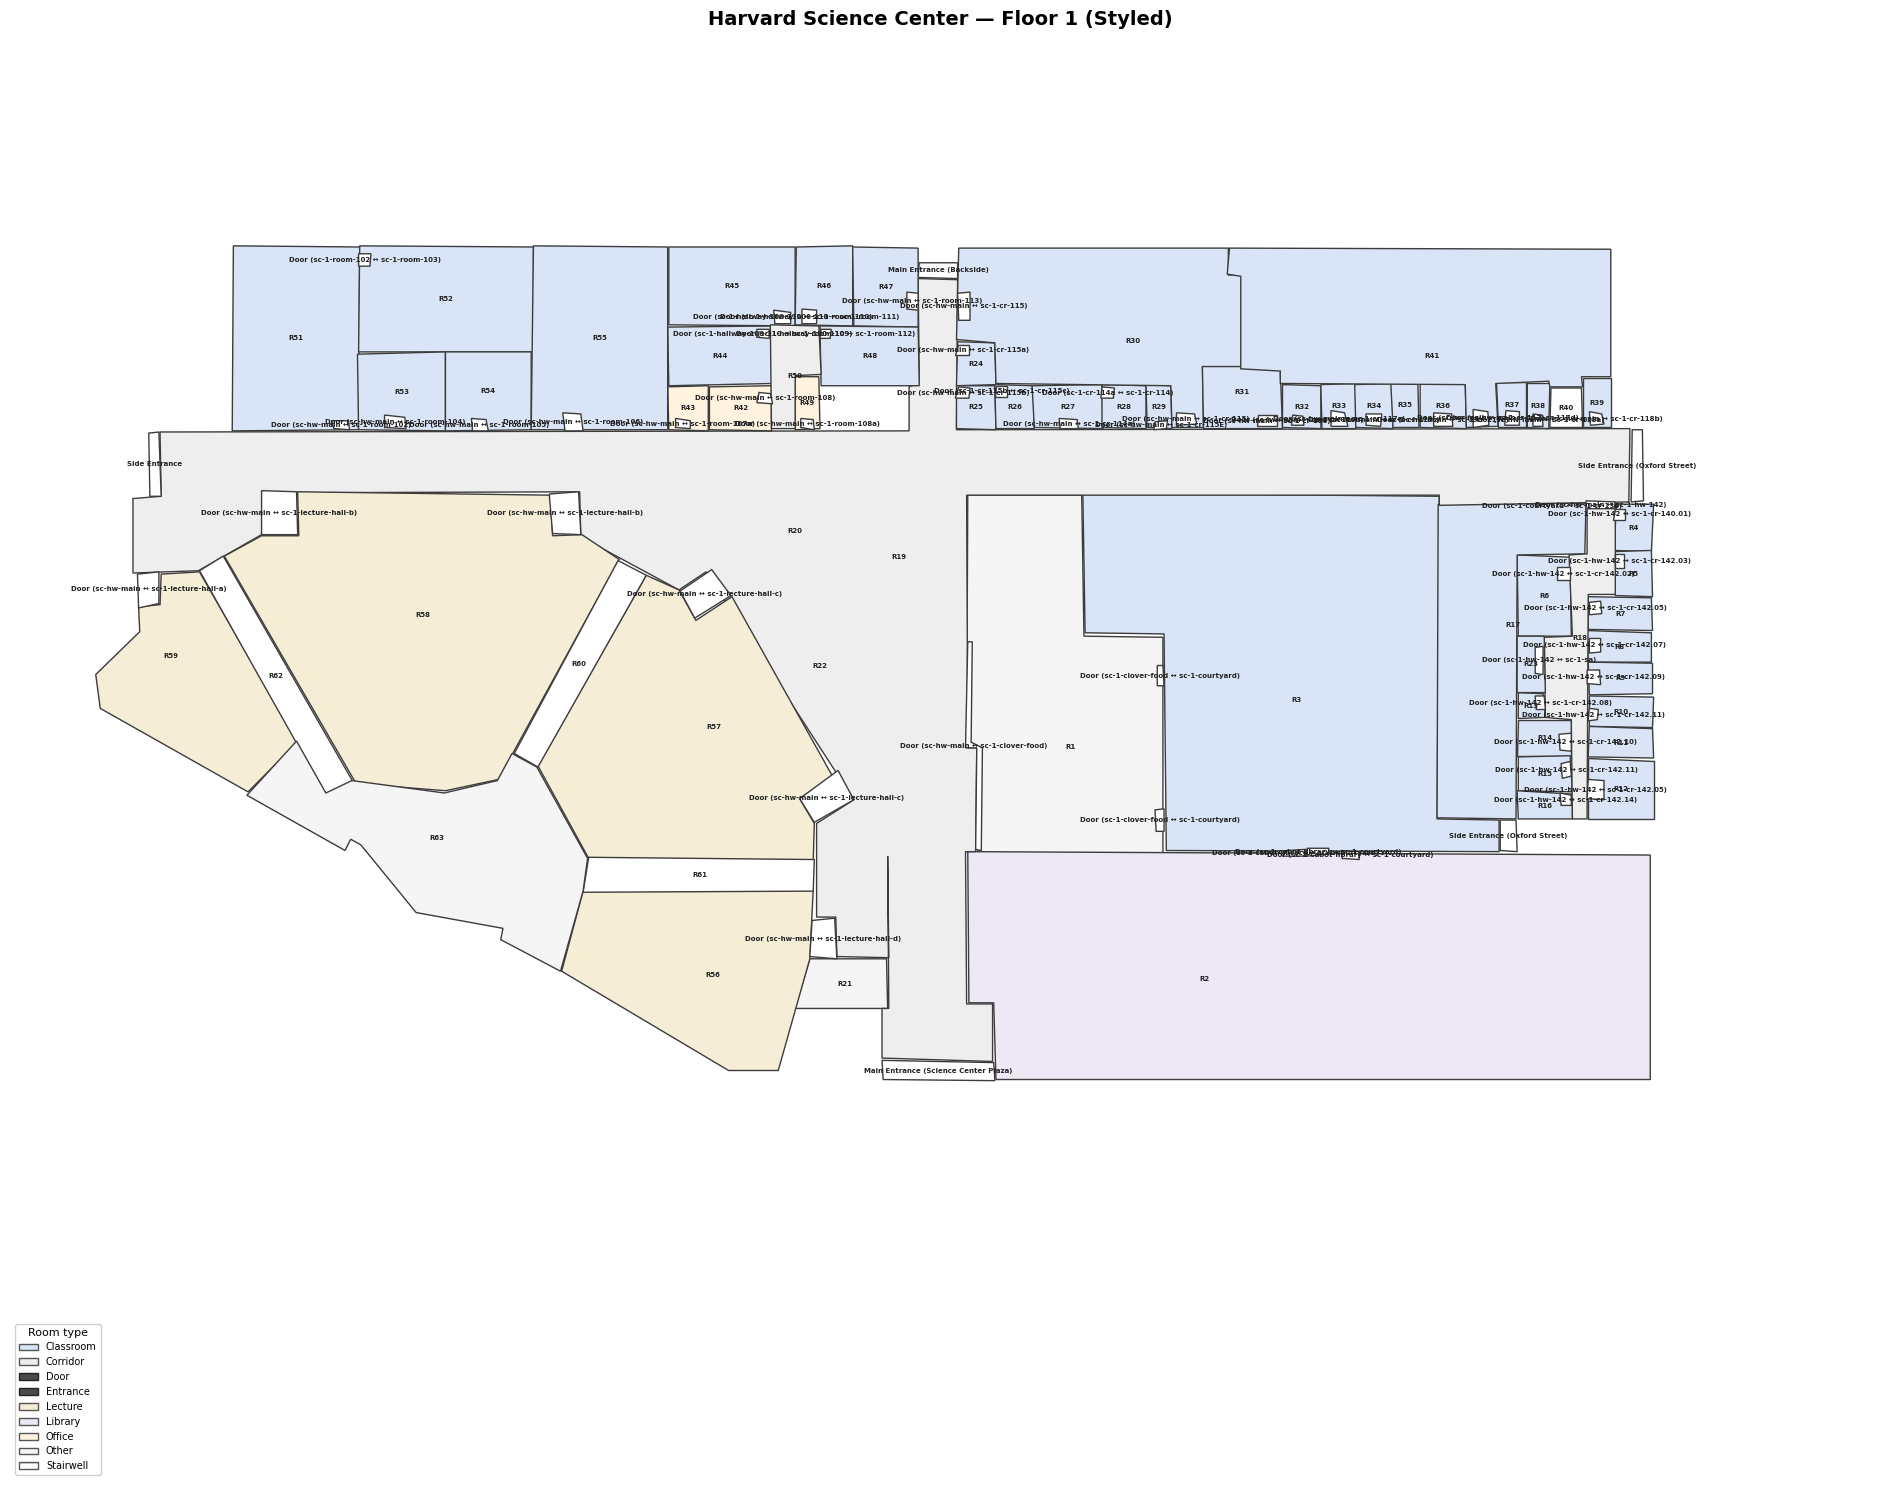

Rooms rendered: 125


In [1]:
import json, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D

with open('Floor Plans/floor1_round_doors.json') as f:
    floor1s = json.load(f)

TYPE_COLORS = {
    'classroom':  '#D9E5F7',
    'lecture':    '#F5EDD6',
    'lobby':      '#FDF6E3',
    'corridor':   '#EEEEEE',
    'connection': '#E0F7FA',
    'door':       '#FFFFFF',
    'entrance':   '#FFFFFF',
    'lab':        '#DAF0DE',
    'library':    '#EDE7F6',
    'stairwell':  '#FFFFFF',
    'elevator':   '#CFD8DC',
    'office':     '#FFF3E0',
    'other':      '#F5F5F5',
}

W = floor1s['viewBox']['width']
H = floor1s['viewBox']['height']

fig, ax = plt.subplots(figsize=(20, 15))
ax.set_facecolor('#E8E0D0')
fig.patch.set_facecolor('#FFFFFF')

legend_done = set()

# Renumber non-door rooms to R[Number]
room_counter = 1
for room in floor1s['rooms']:
    if room.get('symbol', ''):
        continue
    is_door = room['type'] in ('door', 'entrance', 'connection')
    if not is_door:
        room['name'] = f'R{room_counter}'
        room_counter += 1

# Pass 1: draw all regular rooms first (zorder=2)
for room in floor1s['rooms']:
    if room.get('symbol', ''):
        continue
    pts = np.array(room['polygon'], dtype=float)
    pts[:, 1] = H - pts[:, 1]
    t = room['type']
    color = TYPE_COLORS.get(t, '#EEEEEE')
    cx, cy = pts[:, 0].mean(), pts[:, 1].mean()
    poly = Polygon(pts, closed=True, facecolor=color, edgecolor='#3C3C3C',
                   linewidth=1.0, zorder=2)
    ax.add_patch(poly)
    if room['name']:
        ax.text(cx, cy, room['name'], ha='center', va='center',
                fontsize=5, fontweight='bold', color='#222', zorder=3)
    if t not in legend_done:
        legend_done.add(t)

# Pass 2: draw stairwells on top (zorder=4) so they show through corridors
for room in floor1s['rooms']:
    if room.get('symbol', '') != 'hatch_diagonal':
        continue
    pts = np.array(room['polygon'], dtype=float)
    pts[:, 1] = H - pts[:, 1]
    bbox_w = pts[:, 0].max() - pts[:, 0].min()
    bbox_h = pts[:, 1].max() - pts[:, 1].min()
    hatch = '--' if bbox_h >= bbox_w else '||'
    poly = Polygon(pts, closed=True, facecolor='white', edgecolor='#3C3C3C',
                   hatch=hatch, linewidth=1.2, zorder=4)
    ax.add_patch(poly)
    t = room['type']
    if t not in legend_done:
        legend_done.add(t)

# Pass 3: draw doors on top of everything (zorder=5)
for room in floor1s['rooms']:
    if room.get('symbol', '') != 'door_arc':
        continue
    pts = np.array(room['polygon'], dtype=float)
    pts[:, 1] = H - pts[:, 1]
    poly = Polygon(pts, closed=True, facecolor='#4A4A4A', edgecolor='#222222',
                   linewidth=0.6, zorder=5)
    ax.add_patch(poly)
    t = room['type']
    if t not in legend_done:
        legend_done.add(t)

# Legend
legend_handles = []
for t in sorted(legend_done):
    if t == 'stairwell':
        legend_handles.append(
            mpatches.Patch(facecolor='white', edgecolor='#555',
                           hatch='--', label='Stairwell'))
    elif t in ('door', 'entrance', 'connection'):
        legend_handles.append(
            mpatches.Patch(facecolor='#4A4A4A', edgecolor='#222',
                           label=t.capitalize()))
    else:
        legend_handles.append(
            mpatches.Patch(facecolor=TYPE_COLORS.get(t, '#EEE'),
                           edgecolor='#555', label=t.capitalize()))

ax.legend(handles=legend_handles, loc='lower left',
          fontsize=7, framealpha=0.9,
          title='Room type', title_fontsize=8)

ax.set_xlim(0, W)
ax.set_ylim(0, H)
ax.set_aspect('equal')
ax.set_title('Harvard Science Center — Floor 1 (Styled)', fontsize=14,
             fontweight='bold', pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()
print(f'Rooms rendered: {len(floor1s["rooms"])}')


In [2]:
# ── Navigation  ────────────────────────────────────────────────────────────────
# Set START and END to any room name shown in the list below.
# Names are case-insensitive and allow partial matches.

START = "R102"
END   = "Clover"

# ── Setup ───────────────────────────────────────────────────────────────────────
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D
from collections import deque

with open('Floor Plans/floor1_round_doors.json') as f:
    floor1s = json.load(f)

# Renumber non-door rooms to R[Number]
room_counter = 1
for room in floor1s['rooms']:
    if room.get('symbol', ''):
        continue
    is_door = room['type'] in ('door', 'entrance', 'connection')
    if not is_door:
        room['name'] = f'R{room_counter}'
        room_counter += 1

rooms_by_id   = {r['id']: r for r in floor1s['rooms']}
rooms_by_name = {r['name'].lower(): r['id']
                 for r in floor1s['rooms'] if r.get('name')}

# Only these types may be used as intermediate waypoints.
TRAVERSABLE = {'corridor', 'connection', 'door', 'entrance', 'stairwell', 'elevator'}

W = floor1s['viewBox']['width']
H = floor1s['viewBox']['height']

# Door entities: polygon rooms with symbol='door_arc'
door_entities = [r for r in floor1s['rooms'] if r.get('symbol') == 'door_arc']

def resolve(query):
    q = query.lower()
    if q in rooms_by_id:   return q
    if q in rooms_by_name: return rooms_by_name[q]
    matches = [rid for name, rid in rooms_by_name.items() if q in name]
    if len(matches) == 1:  return matches[0]
    if len(matches) > 1:
        raise ValueError(f"Ambiguous — did you mean: {[rooms_by_id[m]['name'] for m in matches]}")
    raise ValueError(f"Room not found: '{query}'")

def bfs(start_id, end_id):
    """Shortest path through hallways/doors only; rooms are only start/end."""
    visited = {start_id}
    queue   = deque([[start_id]])
    while queue:
        path = queue.popleft()
        if path[-1] == end_id:
            return path
        for nb in rooms_by_id.get(path[-1], {}).get('neighbors', []):
            if nb not in visited and nb in rooms_by_id:
                if nb == end_id or rooms_by_id[nb]['type'] in TRAVERSABLE:
                    visited.add(nb)
                    queue.append(path + [nb])
    return None

def find_door_pos(a_id, b_id):
    """Return (x, y) of the door entity that connects room a and room b, or None."""
    na = a_id.replace('.', '-')
    nb = b_id.replace('.', '-')
    for d in door_entities:
        nd = d['id'].replace('.', '-')
        if na in nd and nb in nd:
            la = d.get('labelAnchor', {})
            if la:
                return (la['x'], H - la['y'])
    return None

def build_path_vertices(route_xy):
    """
    Mixed routing:
      room_center -> first_door : vertical-first  (stays inside room)
      door -> door              : horizontal-first (travels along hallway near room walls)
      last_door -> room_center  : horizontal-then-vertical
    """
    if len(route_xy) < 2:
        return list(route_xy)
    start = route_xy[0]
    end   = route_xy[-1]
    doors = route_xy[1:-1]
    verts = [start]
    if doors:
        verts.append((start[0], doors[0][1]))  # vertical to first door y
        verts.append(doors[0])                  # horizontal to first door x
        for i in range(len(doors) - 1):
            x0, y0 = doors[i]
            x1, y1 = doors[i + 1]
            verts.append((x1, y0))  # horizontal to next door x
            verts.append((x1, y1))  # vertical to next door y
        verts.append((end[0], doors[-1][1]))  # horizontal to end room x
        verts.append(end)                      # vertical to end room center
    else:
        verts.append((start[0], end[1]))
        verts.append(end)
    return verts

# ── Find path ──────────────────────────────────────────────────────────────────
start_id = resolve(START)
end_id   = resolve(END)
path_ids = bfs(start_id, end_id)

if path_ids is None:
    print(f"No path found from '{START}' to '{END}'.")
    print("Check that both rooms connect via indoor hallways/doors.")
else:
    path_names = [rooms_by_id[p]['name'] or p for p in path_ids]
    print(f"Path ({len(path_ids)} steps):  " + "  →  ".join(path_names))

    # ── Build route through actual door positions ──────────────────────────────
    # route_xy = [start_center, door1_anchor, door2_anchor, ..., end_center]
    # Corridor room centers are skipped — the line passes through door openings.
    route_xy = []

    # Start room center
    la = rooms_by_id[start_id].get('labelAnchor', {})
    if la:
        route_xy.append((la['x'], H - la['y']))

    # For each consecutive pair, look for a door entity at their boundary
    for i in range(len(path_ids) - 1):
        door_pos = find_door_pos(path_ids[i], path_ids[i + 1])
        if door_pos:
            route_xy.append(door_pos)
        else:
            # No door entity found — fall back to room labelAnchor
            la = rooms_by_id[path_ids[i + 1]].get('labelAnchor', {})
            if la:
                route_xy.append((la['x'], H - la['y']))

    # End room center
    la = rooms_by_id[end_id].get('labelAnchor', {})
    if la:
        route_xy.append((la['x'], H - la['y']))

    # ── Render ─────────────────────────────────────────────────────────────────
    TYPE_COLORS = {
        'classroom': '#D9E5F7', 'lecture':  '#F5EDD6', 'lobby':    '#FDF6E3',
        'corridor':  '#EEEEEE', 'connection':'#E0F7FA', 'door':     '#FFFFFF',
        'entrance':  '#FFFFFF', 'lab':      '#DAF0DE', 'library':  '#EDE7F6',
        'stairwell': '#FFFFFF', 'elevator': '#CFD8DC', 'office':   '#FFF3E0',
        'other':     '#F5F5F5',
    }
    PATH_COLOR  = '#FFB703'
    START_COLOR = '#2DC653'
    END_COLOR   = '#E63946'
    LINE_COLOR  = '#023E8A'
    path_set = set(path_ids)

    fig, ax = plt.subplots(figsize=(20, 15))
    ax.set_facecolor('#E8E0D0')
    fig.patch.set_facecolor('#FFFFFF')

    # Pass 1 — regular rooms
    for room in floor1s['rooms']:
        if room.get('symbol', ''):
            continue
        pts = np.array(room['polygon'], dtype=float)
        pts[:, 1] = H - pts[:, 1]
        rid = room['id']
        if rid == start_id:      fc = START_COLOR
        elif rid == end_id:      fc = END_COLOR
        elif rid in path_set:    fc = PATH_COLOR
        else:                    fc = TYPE_COLORS.get(room['type'], '#EEEEEE')
        ax.add_patch(Polygon(pts, closed=True, facecolor=fc,
                             edgecolor='#3C3C3C', linewidth=1.0, zorder=2))
        if room['name']:
            cx, cy = pts[:, 0].mean(), pts[:, 1].mean()
            ax.text(cx, cy, room['name'], ha='center', va='center',
                    fontsize=5,
                    fontweight='bold' if rid in path_set else 'normal',
                    color='#000' if rid in path_set else '#555', zorder=3)

    # Pass 2 — stairwells
    for room in floor1s['rooms']:
        if room.get('symbol', '') != 'hatch_diagonal':
            continue
        pts = np.array(room['polygon'], dtype=float)
        pts[:, 1] = H - pts[:, 1]
        bw = pts[:, 0].max() - pts[:, 0].min()
        bh = pts[:, 1].max() - pts[:, 1].min()
        hatch = '--' if bh >= bw else '||'
        fc = PATH_COLOR if room['id'] in path_set else 'white'
        ax.add_patch(Polygon(pts, closed=True, facecolor=fc,
                             edgecolor='#3C3C3C', hatch=hatch,
                             linewidth=1.2, zorder=4))

    # Pass 3 — doors
    for room in floor1s['rooms']:
        if room.get('symbol', '') != 'door_arc':
            continue
        pts = np.array(room['polygon'], dtype=float)
        pts[:, 1] = H - pts[:, 1]
        ax.add_patch(Polygon(pts, closed=True, facecolor='#4A4A4A',
                             edgecolor='#222222', linewidth=0.6, zorder=5))

    # Pass 4 — path line (horizontal along hallway, vertical into rooms)
    if len(route_xy) >= 2:
        verts = build_path_vertices(route_xy)
        xs = [p[0] for p in verts]
        ys = [p[1] for p in verts]
        ax.plot(xs, ys, color=LINE_COLOR, linewidth=3.5,
                linestyle='-',  zorder=6, alpha=0.95,
                solid_capstyle='round', solid_joinstyle='round')

        # Directional arrows at each segment midpoint
        for i in range(len(xs) - 1):
            x0, y0, x1, y1 = xs[i], ys[i], xs[i + 1], ys[i + 1]
            if abs(x1 - x0) < 1 and abs(y1 - y0) < 1:
                continue
            cx_, cy_ = (x0 + x1) / 2, (y0 + y1) / 2
            dx, dy = (x1 - x0) * 0.001, (y1 - y0) * 0.001
            ax.annotate('', xy=(cx_ + dx, cy_ + dy), xytext=(cx_ - dx, cy_ - dy),
                        arrowprops=dict(arrowstyle='->', color=LINE_COLOR, lw=1.8),
                        zorder=7)

        # S / E labels at start and end
        for i, (x, y) in enumerate(route_xy):
            if i == 0:
                label, fc_ = 'S', START_COLOR
            elif i == len(route_xy) - 1:
                label, fc_ = 'E', END_COLOR
            else:
                continue
            ax.text(x, y, label, ha='center', va='center', fontsize=6,
                    fontweight='bold', color='white', zorder=9,
                    bbox=dict(boxstyle='circle,pad=0.25', facecolor=fc_,
                              edgecolor='white', linewidth=0.8))

    legend_entries = [
        mpatches.Patch(facecolor=START_COLOR, edgecolor='#333',
                       label=f'Start: {rooms_by_id[start_id]["name"]}'),
        mpatches.Patch(facecolor=END_COLOR,   edgecolor='#333',
                       label=f'End: {rooms_by_id[end_id]["name"]}'),
        mpatches.Patch(facecolor=PATH_COLOR,  edgecolor='#333', label='On route'),
        Line2D([0], [0], color=LINE_COLOR, linewidth=2,
               linestyle='-',  label='Path'),
    ]
    ax.legend(handles=legend_entries, loc='lower left',
              fontsize=8, framealpha=0.92, title='Navigation', title_fontsize=9)
    ax.set_xlim(0, W); ax.set_ylim(0, H); ax.set_aspect('equal')
    ax.set_title(
        f'Navigation: {rooms_by_id[start_id]["name"]}  →  {rooms_by_id[end_id]["name"]}',
        fontsize=14, fontweight='bold', pad=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# ── Available rooms ─────────────────────────────────────────────────────────────
print("\nAvailable rooms (start / end):")
nav_rooms = sorted(
    {r['name'] for r in floor1s['rooms']
     if r.get('name') and r.get('neighbors')
     and r['type'] not in ('door', 'entrance', 'connection')},
    key=str.lower
)
for i in range(0, len(nav_rooms), 4):
    print("  " + "   ".join(f"{n:<22}" for n in nav_rooms[i:i+4]))


ValueError: Room not found: 'R102'